## Assignment 4

<br>

### Question 1
Investigate the model for predicting Diabetes disease progression by adding more explanatory variables to it in addition to `bmi` and `s5`.

a) Which variable would you add next? Why?

b) How does adding it affect the model's performance? Compute metrics and compare to having just `bmi` and `s5`.

d) Does it help if you add even more variables?

Include your own findings and explanations in code comments or inside triple quotes """...""".

In [11]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load diabetes dataset directly from sklearn
diabetes = load_diabetes(as_frame=True)

data = diabetes.frame
data.columns = list(diabetes.feature_names) + ['Y']

X = data.drop('Y', axis=1)
y = data['Y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline model using bmi and s5 only
baseline = LinearRegression()
baseline.fit(X_train[['bmi', 's5']], y_train)

pred_base = baseline.predict(X_test[['bmi', 's5']])

r2_base = r2_score(y_test, pred_base)
rmse_base = mean_squared_error(y_test, pred_base) ** 0.5

print("Baseline Model (bmi + s5)")
print("R2 Score:", round(r2_base,4))
print("RMSE:", round(rmse_base,4))

# Find the next best variable by correlation with Y
corr = data.corr(numeric_only=True)['Y'].drop('Y').sort_values(
    key=abs, ascending=False
)

print("\nCorrelation with target Y")
print(corr)

next_variable = corr.index[2]   # bmi and s5 are already used
print("\nNext variable chosen:", next_variable)

# Model with one extra variable
features = ['bmi','s5',next_variable]

model2 = LinearRegression()
model2.fit(X_train[features], y_train)

pred2 = model2.predict(X_test[features])

r2_2 = r2_score(y_test, pred2)
rmse_2 = mean_squared_error(y_test, pred2) ** 0.5

print("\nModel with additional variable")
print("Features:", features)
print("R2 Score:", round(r2_2,4))
print("RMSE:", round(rmse_2,4))

# Model using all variables
full_model = LinearRegression()
full_model.fit(X_train, y_train)

pred_full = full_model.predict(X_test)

r2_full = r2_score(y_test, pred_full)
rmse_full = mean_squared_error(y_test, pred_full) ** 0.5

print("\nModel with all variables")
print("R2 Score:", round(r2_full,4))
print("RMSE:", round(rmse_full,4))


Baseline Model (bmi + s5)
R2 Score: 0.4523
RMSE: 53.8687

Correlation with target Y
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: Y, dtype: float64

Next variable chosen: bp

Model with additional variable
Features: ['bmi', 's5', 'bp']
R2 Score: 0.4543
RMSE: 53.7684

Model with all variables
R2 Score: 0.4526
RMSE: 53.8534


### Question 2

Consider the dataset `50_Startups.csv` which contains data for companies' profit etc.

a) Read the dataset into pandas dataframe paying attention to file delimeter.

b) Identify the variables inside the dataset

c) Investigate the correlation between the variables

d) Choose appropriate variables to predict company profit. Justify your choice.

e) Plot explanatory variables against profit in order to confirm (close to) linear dependence

f) Form training and testing data (80/20 split)

g) Train linear regression model with training data

h) Compute RMSE and $R^2$ values for training and testing data separately

Include your own findings and explanations in code comments or inside triple quotes """...""".

### Question 3

Consider car performance data from the file `Auto.csv`.

a) Read the data into pandas dataframe

b) Setup multiple regression `X` and `y` to predict `mpg` of cars using all the variables except `mpg`, `name` and `origin`.

c) Split data into training and testing sets (80/20 split)

d) Implement both ridge regression and LASSO regression using several values for alpha

e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data

f) Plot the R2 scores for both regressors as functions of alpha

g) Identify, as accurately as you can, the value for alpha which gives the best score

 
Include your own findings and explanations in code comments or inside triple quotes """...""".

Dataset loaded successfully.

First 5 rows:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



Dataset Shape:
(50, 5)

Column Names:
['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']

Data Types:
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB

Missing Values:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Correlation Matrix:
                 R&D Spend  Administration  Marketing Spend    Profit
R&D S

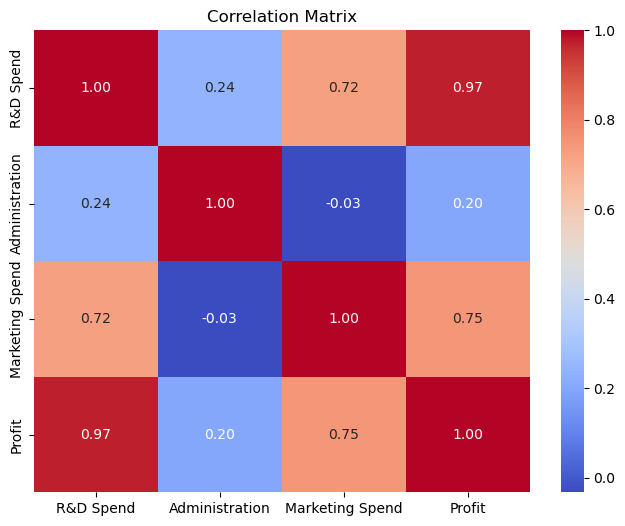


Columns after encoding:
['R&D Spend', 'Administration', 'Marketing Spend', 'Profit', 'State_Florida', 'State_New York']


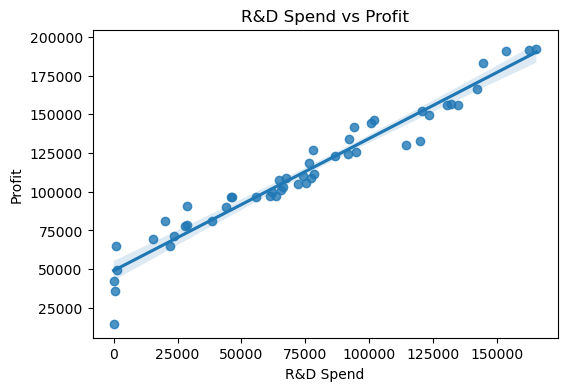

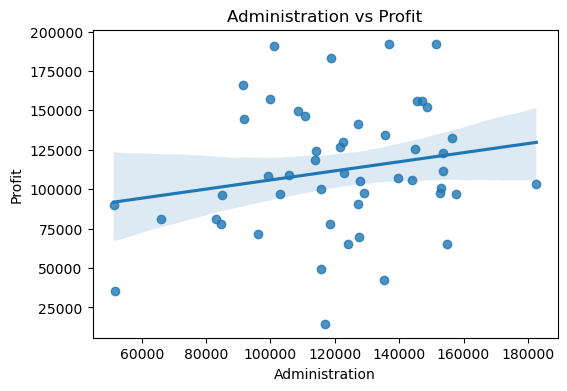

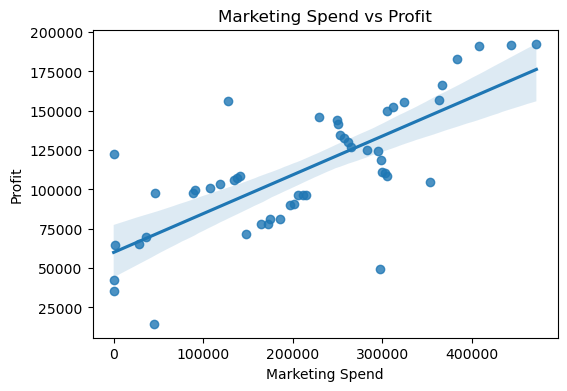


Training Data Shape:
(40, 5)

Testing Data Shape:
(10, 5)

Model trained successfully.

Regression Coefficients:


,Variable,Coefficient
0,R&D Spend,0.805630
1,Administration,-0.068788
2,Marketing Spend,0.029855
3,State_Florida,938.793006
4,State_New York,6.987760


Intercept:
54028.039593645844

MODEL PERFORMANCE
Training RMSE : 8927.49
Testing RMSE  : 9055.96

Training R²   : 0.9537
Testing R²    : 0.8987

Sample Predictions:


,Actual Profit,Predicted Profit
13,134307.35,126362.879083
39,81005.76,84608.453836
30,99937.59,99677.494251
45,64926.08,46357.460686
17,125370.37,128750.482885


In [8]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("50_Startups.csv")

print("Dataset loaded successfully.")
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


df_encoded = pd.get_dummies(
    df,
    columns=["State"],
    drop_first=True
)

print("\nColumns after encoding:")
print(df_encoded.columns.tolist())


features = [
    "R&D Spend",
    "Administration",
    "Marketing Spend"
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.regplot(
        x=df[feature],
        y=df["Profit"]
    )

    plt.title(f"{feature} vs Profit")
    plt.xlabel(feature)
    plt.ylabel("Profit")

    plt.show()


X = df_encoded.drop("Profit", axis=1)
y = df_encoded["Profit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel trained successfully.")


coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

print("\nRegression Coefficients:")
display(coefficients)

print("Intercept:")
print(model.intercept_)


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# RMSE

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

# R²

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"Training RMSE : {train_rmse:.2f}")
print(f"Testing RMSE  : {test_rmse:.2f}")

print()

print(f"Training R²   : {train_r2:.4f}")
print(f"Testing R²    : {test_r2:.4f}")

results = pd.DataFrame({
    "Actual Profit": y_test,
    "Predicted Profit": y_test_pred
})

print("\nSample Predictions:")
display(results.head())


First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



Dataset Shape:
(397, 9)

Column Names:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']

Shape after removing missing values:
(392, 9)

Predictor Variables:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

Training Shape: (313, 6)
Testing Shape : (79, 6)

RIDGE REGRESSION
Best Alpha : 0.0001
Best Test R² : 0.7942

LASSO REGRESSION
Best Alpha : 0.6579332246575675
Best Test R² : 0.8054


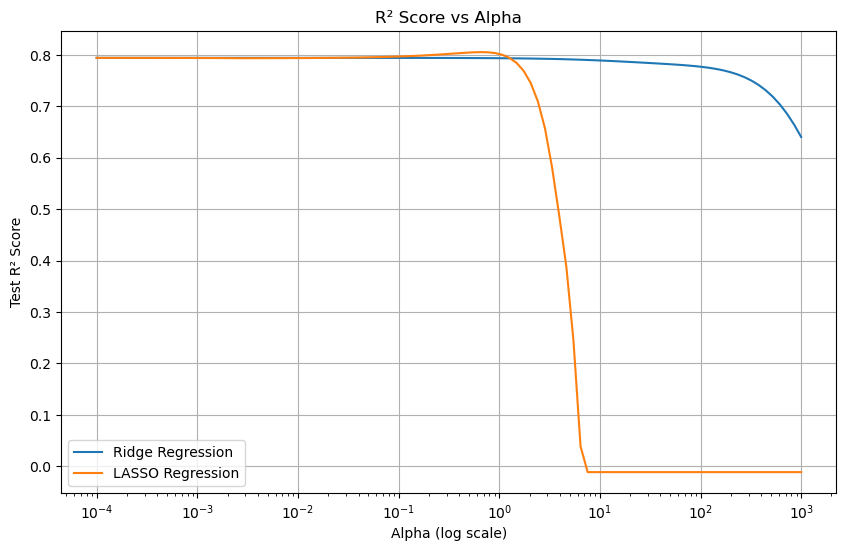

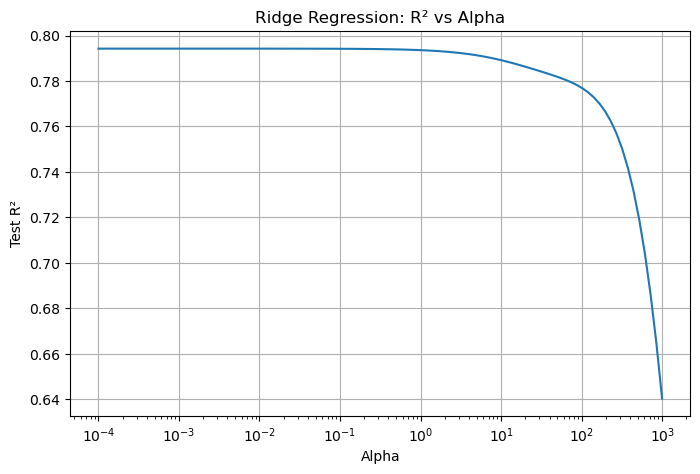

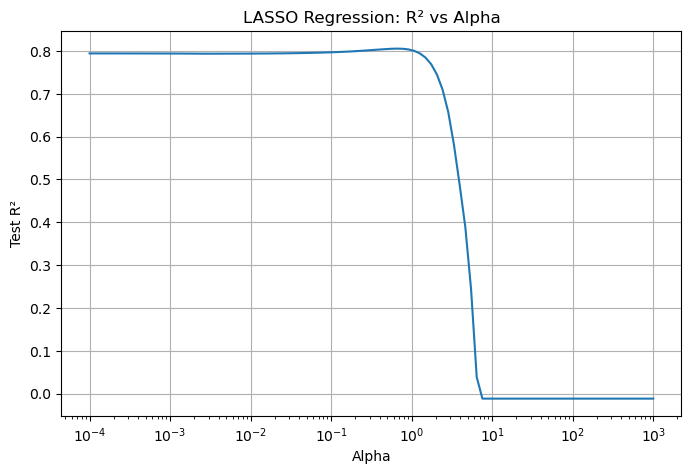

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import r2_score

df = pd.read_csv("Auto.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

if 'horsepower' in df.columns:

    df['horsepower'] = pd.to_numeric(
        df['horsepower'],
        errors='coerce'
    )

df.dropna(inplace=True)

print("\nShape after removing missing values:")
print(df.shape)

X = df.drop(
    columns=["mpg", "name", "origin"]
)

y = df["mpg"]

print("\nPredictor Variables:")
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
alphas = np.logspace(-4, 3, 100)

ridge_scores = []
lasso_scores = []

best_ridge_alpha = None
best_ridge_score = -np.inf

best_lasso_alpha = None
best_lasso_score = -np.inf

for alpha in alphas:

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(
        X_train_scaled,
        y_train
    )

    ridge_pred = ridge_model.predict(
        X_test_scaled
    )

    ridge_r2 = r2_score(
        y_test,
        ridge_pred
    )

    ridge_scores.append(ridge_r2)

    if ridge_r2 > best_ridge_score:
        best_ridge_score = ridge_r2
        best_ridge_alpha = alpha

    # LASSO
    lasso_model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso_model.fit(
        X_train_scaled,
        y_train
    )

    lasso_pred = lasso_model.predict(
        X_test_scaled
    )

    lasso_r2 = r2_score(
        y_test,
        lasso_pred
    )

    lasso_scores.append(lasso_r2)

    if lasso_r2 > best_lasso_score:
        best_lasso_score = lasso_r2
        best_lasso_alpha = alpha

print("\n================================")
print("RIDGE REGRESSION")
print("================================")

print("Best Alpha :", best_ridge_alpha)
print("Best Test R² :", round(best_ridge_score, 4))

print("\n================================")
print("LASSO REGRESSION")
print("================================")

print("Best Alpha :", best_lasso_alpha)
print("Best Test R² :", round(best_lasso_score, 4))

plt.figure(figsize=(10,6))

plt.semilogx(
    alphas,
    ridge_scores,
    label="Ridge Regression"
)

plt.semilogx(
    alphas,
    lasso_scores,
    label="LASSO Regression"
)

plt.xlabel("Alpha (log scale)")
plt.ylabel("Test R² Score")
plt.title("R² Score vs Alpha")

plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.semilogx(
    alphas,
    ridge_scores
)

plt.xlabel("Alpha")
plt.ylabel("Test R²")
plt.title("Ridge Regression: R² vs Alpha")

plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.semilogx(
    alphas,
    lasso_scores
)

plt.xlabel("Alpha")
plt.ylabel("Test R²")
plt.title("LASSO Regression: R² vs Alpha")

plt.grid(True)
plt.show()
